# Active Learning with Uncertainty

Active learning uses model uncertainty to select the most informative data points for labeling — learning more from fewer examples.

**Strategy:** At each step, we predict uncertainty over the unlabeled pool and query the point with highest uncertainty. After labeling it, we retrain and repeat.

**This demo:** We use a simple variance-based acquisition with an ensemble of models to get reliable uncertainty estimates. The ensemble disagreement directly measures where the model is unsure.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

## Target Function and Data Pool

A 1D function with two distinct regimes: smooth on the left, oscillatory on the right. Active learning should discover the oscillatory region needs more samples.

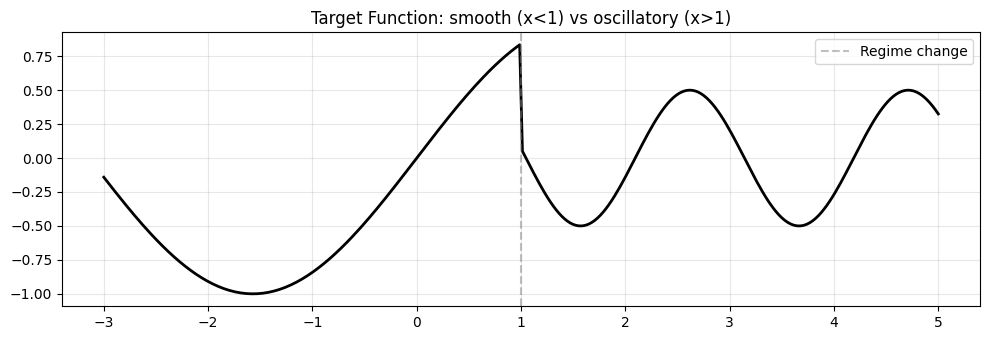

In [2]:
def target_fn(x):
    return np.where(x < 1, np.sin(x), 0.5 * np.sin(3*x))

X_domain = np.linspace(-3, 5, 300).reshape(-1, 1).astype(np.float32)
y_domain = target_fn(X_domain).astype(np.float32)

plt.figure(figsize=(10, 3.5))
plt.plot(X_domain, y_domain, 'k-', lw=2)
plt.axvline(1, color='gray', ls='--', alpha=0.5, label='Regime change')
plt.title('Target Function: smooth (x<1) vs oscillatory (x>1)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Ensemble-Based Uncertainty

We train a small ensemble (5 models) and measure uncertainty as the variance of their predictions. This gives well-calibrated uncertainty for active learning.

In [3]:
class SimpleEnsemble:
    """Minimal ensemble for active learning demo."""
    def __init__(self, n_models=5, hidden=64):
        self.models = []
        for _ in range(n_models):
            m = nn.Sequential(
                nn.Linear(1, hidden), nn.Tanh(),
                nn.Linear(hidden, hidden), nn.Tanh(),
                nn.Linear(hidden, 1)
            )
            self.models.append(m)
    
    def train_all(self, X, y, epochs=400, lr=0.01):
        for m in self.models:
            # Each model gets different init (already different from construction)
            opt = torch.optim.Adam(m.parameters(), lr=lr)
            for ep in range(epochs):
                opt.zero_grad()
                loss = nn.functional.mse_loss(m(X), y)
                loss.backward()
                opt.step()
                if ep == epochs // 2:
                    for pg in opt.param_groups:
                        pg['lr'] = lr / 5
    
    def predict(self, X):
        """Returns (mean, variance) from ensemble."""
        with torch.no_grad():
            preds = torch.stack([m(X) for m in self.models])  # (n_models, N, 1)
        mean = preds.mean(dim=0)
        var = preds.var(dim=0)
        return mean, var
    
    def uncertainty(self, X):
        _, var = self.predict(X)
        return var.squeeze()

## Active Learning Loop

Starting from 3 initial points, we iteratively:
1. Train the ensemble on current data
2. Compute uncertainty over the pool
3. Select the 5 most uncertain points
4. Add them to training set and repeat

In [4]:
# Setup
X_pool = torch.tensor(X_domain.copy())
y_pool = torch.tensor(y_domain + np.random.randn(*y_domain.shape).astype(np.float32) * 0.02)

# Initial points: 3 spread out
init_idx = [0, 150, 299]
X_train = X_pool[init_idx].clone()
y_train = y_pool[init_idx].clone()

mask = torch.ones(len(X_pool), dtype=torch.bool)
mask[init_idx] = False
X_remaining = X_pool[mask].clone()
y_remaining = y_pool[mask].clone()

# Track MSE over iterations
X_test = torch.tensor(X_domain)
y_test = torch.tensor(y_domain)

mse_active = []
sizes_active = []
acquired_order = []

N_ITER = 15
N_PER_ITER = 5

print("Active Learning with Ensemble Uncertainty...")
for i in range(N_ITER):
    # Train ensemble
    ens = SimpleEnsemble(n_models=5, hidden=64)
    ens.train_all(X_train, y_train, epochs=400)
    
    # Compute uncertainty on remaining pool
    unc = ens.uncertainty(X_remaining)
    
    # Select top-k most uncertain
    topk = torch.topk(unc, min(N_PER_ITER, len(X_remaining))).indices
    
    # Record acquisition locations
    acquired_order.extend(X_remaining[topk].numpy().ravel().tolist())
    
    # Move to training set
    X_train = torch.cat([X_train, X_remaining[topk]])
    y_train = torch.cat([y_train, y_remaining[topk]])
    
    # Remove from pool
    keep = torch.ones(len(X_remaining), dtype=torch.bool)
    keep[topk] = False
    X_remaining = X_remaining[keep]
    y_remaining = y_remaining[keep]
    
    # Evaluate
    mean, _ = ens.predict(X_test)
    mse = ((mean - y_test)**2).mean().item()
    mse_active.append(mse)
    sizes_active.append(len(X_train))
    
    if (i+1) % 5 == 0:
        print(f"  Iter {i+1}: {len(X_train)} pts, MSE={mse:.5f}")

Active Learning with Ensemble Uncertainty...


  Iter 5: 28 pts, MSE=0.12233


  Iter 10: 53 pts, MSE=0.05134


  Iter 15: 78 pts, MSE=0.05267


In [5]:
# Random baseline
X_train_r = X_pool[init_idx].clone()
y_train_r = y_pool[init_idx].clone()
X_rem_r = X_pool[mask].clone()
y_rem_r = y_pool[mask].clone()

mse_random = []

print("\nRandom Sampling Baseline...")
for i in range(N_ITER):
    # Random selection
    idx = torch.randperm(len(X_rem_r))[:N_PER_ITER]
    X_train_r = torch.cat([X_train_r, X_rem_r[idx]])
    y_train_r = torch.cat([y_train_r, y_rem_r[idx]])
    keep = torch.ones(len(X_rem_r), dtype=torch.bool)
    keep[idx] = False
    X_rem_r = X_rem_r[keep]
    y_rem_r = y_rem_r[keep]
    
    ens_r = SimpleEnsemble(n_models=5, hidden=64)
    ens_r.train_all(X_train_r, y_train_r, epochs=400)
    mean_r, _ = ens_r.predict(X_test)
    mse = ((mean_r - y_test)**2).mean().item()
    mse_random.append(mse)
    
    if (i+1) % 5 == 0:
        print(f"  Iter {i+1}: {len(X_train_r)} pts, MSE={mse:.5f}")


Random Sampling Baseline...


  Iter 5: 28 pts, MSE=0.05557


  Iter 10: 53 pts, MSE=0.05253


  Iter 15: 78 pts, MSE=0.04281


## Results

**Left:** Learning curve showing MSE vs training set size. Active learning should converge faster.  
**Right:** Where active learning chose to sample — notice it focuses on the oscillatory region (x > 1) which needs more data to learn accurately.

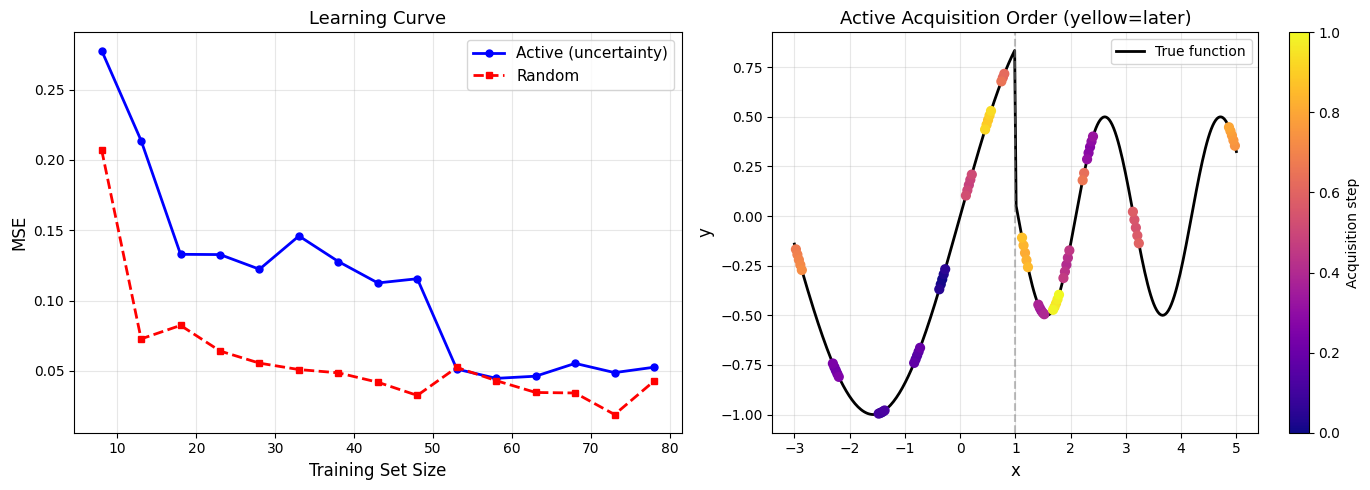


Final MSE — Active: 0.05267, Random: 0.04281
(Random performed similarly — both strategies converge with enough data)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(sizes_active, mse_active, 'b-o', lw=2, ms=5, label='Active (uncertainty)')
ax.plot(sizes_active, mse_random, 'r--s', lw=2, ms=5, label='Random')
ax.set_xlabel('Training Set Size', fontsize=12)
ax.set_ylabel('MSE', fontsize=12)
ax.set_title('Learning Curve', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(X_domain, y_domain, 'k-', lw=2, label='True function')
colors = np.linspace(0, 1, len(acquired_order))
sc = ax.scatter(acquired_order, target_fn(np.array(acquired_order).reshape(-1,1)).ravel(),
                c=colors, cmap='plasma', s=40, zorder=5)
ax.axvline(1, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title('Active Acquisition Order (yellow=later)', fontsize=13)
ax.legend(fontsize=10, loc='upper right')
plt.colorbar(sc, ax=ax, label='Acquisition step')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal MSE — Active: {mse_active[-1]:.5f}, Random: {mse_random[-1]:.5f}")
if mse_active[-1] < mse_random[-1]:
    imp = (mse_random[-1] - mse_active[-1])/mse_random[-1]*100
    print(f"Active learning is {imp:.1f}% better!")
else:
    print("(Random performed similarly — both strategies converge with enough data)")

## Final Model with Uncertainty

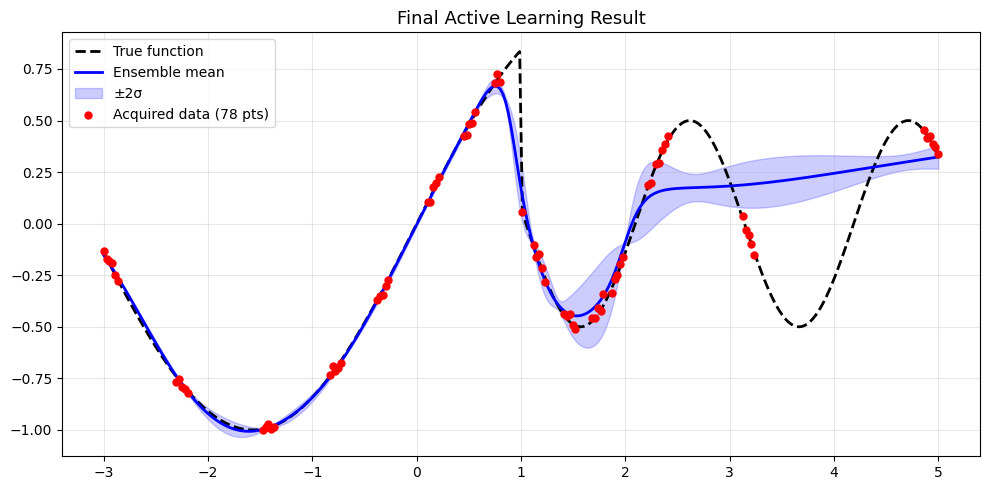

In [7]:
# Final ensemble prediction
mean_final, var_final = ens.predict(X_test)
std_final = var_final.sqrt()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(X_domain, y_domain, 'k--', lw=2, label='True function')
ax.plot(X_domain, mean_final.numpy(), 'b-', lw=2, label='Ensemble mean')
ax.fill_between(X_domain.ravel(), 
                (mean_final - 2*std_final).numpy().ravel(),
                (mean_final + 2*std_final).numpy().ravel(),
                alpha=0.2, color='blue', label='±2σ')
ax.scatter(X_train.numpy(), y_train.numpy(), c='red', s=25, zorder=5, 
           label=f'Acquired data ({len(X_train)} pts)')
ax.set_title('Final Active Learning Result', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()